# Módulo 1 — Churn Prediction
## Notebook 02: Entrenamiento del Modelo

**Qué hace este notebook:**  
Toma los datos de estudiantes de Platzi, los prepara para que el modelo los entienda, entrena un algoritmo de Machine Learning y mide qué tan bien predice quién va a abandonar la plataforma.

**El resultado final:**  
Un modelo guardado que, dado un estudiante nuevo, devuelve la probabilidad de que abandone — por ejemplo: *"este estudiante tiene 78% de probabilidad de churn"*.

---

## 0. Importar librerías

Cargamos todas las herramientas que vamos a necesitar.  
A diferencia del EDA donde usábamos solo pandas y matplotlib, acá traemos `scikit-learn` — la librería central de Machine Learning en Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Preprocesamiento
from sklearn.pipeline         import Pipeline
from sklearn.compose          import ColumnTransformer
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.impute           import SimpleImputer

# División de datos y modelo
from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.ensemble         import RandomForestClassifier

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

sns.set_theme(style='whitegrid')
COLOR_NO_CHURN = '#2ecc71'
COLOR_CHURN    = '#e74c3c'

os.makedirs('../models', exist_ok=True)
print('Todo importado correctamente.')

Todo importado correctamente.


---
## 1. Cargar datos

In [2]:
df = pd.read_csv('../data/raw/platzi_churn.csv')
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Churn rate: {df["churn"].mean():.1%}')

Dataset cargado: 5,000 filas × 58 columnas
Churn rate: 38.2%


---
## 2. Selección de features

**¿Por qué no usamos todas las 58 columnas?**

Algunas columnas no sirven como input del modelo:
- `student_id` → es un identificador, no tiene información útil
- `fecha_registro` → es un texto tipo fecha, el modelo no puede procesarlo directamente
- `dias_para_renovacion` → tiene valor especial (-1) para gratuitos, confunde el modelo
- Las columnas `interes_*` y `horas_semana_*` las guardamos para otros módulos

Seleccionamos las que sí tienen poder predictivo claro.

In [3]:
# Columnas numéricas que vamos a usar
FEATURES_NUMERICAS = [
    'edad',
    'meses_suscrito',
    'cursos_inscritos',
    'cursos_completados',
    'tasa_completado',
    'certificados_obtenidos',
    'rutas_inscritas',
    'rutas_completadas',
    'examenes_ruta_aprobados',
    'dias_desde_ultimo_login',
    'dias_desde_ultima_clase',
    'sesiones_ultimo_mes',
    'horas_vistas_total',
    'horas_vistas_ultimo_mes',
    'promedio_clases_semana',
    'racha_dias_maxima',
    'racha_dias_actual',
    'liveclasses_asistidas',
    'preguntas_en_foro',
    'respuestas_en_foro',
    'upvotes_recibidos',
    'tutoriales_publicados',
    'platzi_rank',
    'tickets_soporte',
    'dias_resolucion_promedio',
    'nps_score',                   # tiene nulos — los manejaremos
    'intentos_pago_fallidos',
    'variacion_sesiones_vs_mes_anterior',
    'experiencia_tech_anios',
    'dias_en_gratuito_antes_pago',
]

# Columnas categóricas (texto) que vamos a usar
FEATURES_CATEGORICAS = [
    'plan',
    'pais',
    'genero',
    'escuela_principal',
    'dispositivo_principal',
    'tipo_pago',
    'objetivo_estudiante',
    'nivel_educativo',
    'nivel_rewards',
]

TODAS_LAS_FEATURES = FEATURES_NUMERICAS + FEATURES_CATEGORICAS
TARGET = 'churn'

print(f'Features numéricas:   {len(FEATURES_NUMERICAS)}')
print(f'Features categóricas: {len(FEATURES_CATEGORICAS)}')
print(f'Total features:       {len(TODAS_LAS_FEATURES)}')

Features numéricas:   30
Features categóricas: 9
Total features:       39


---
## 3. Separar X e y

En Machine Learning siempre separamos los datos en dos partes:
- **X** → las variables de entrada (todo lo que el modelo puede ver de un estudiante)
- **y** → la variable que queremos predecir (si hizo churn o no)

El modelo aprende la relación entre X e y.

In [4]:
X = df[TODAS_LAS_FEATURES]
y = df[TARGET]

print(f'X (entrada):  {X.shape}  — filas × columnas de features')
print(f'y (objetivo): {y.shape}  — un valor por estudiante (0 o 1)')
print(f'\nDistribución de y:')
print(y.value_counts().to_string())

X (entrada):  (5000, 39)  — filas × columnas de features
y (objetivo): (5000,)  — un valor por estudiante (0 o 1)

Distribución de y:
churn
0    3089
1    1911


---
## 4. Dividir en Train y Test

**Este es uno de los pasos más importantes de todo el proceso.**

Dividimos los datos en dos grupos:
- **Train (80%)** → el modelo aprende con estos datos
- **Test (20%)** → evaluamos qué tan bien aprendió con datos que NUNCA vio

Si evaluáramos con los mismos datos que usó para aprender, sería como darle el examen con las respuestas — sacaría 100% pero no aprendería nada.

`stratify=y` garantiza que la proporción de churners sea la misma en train y test. Sin esto, podría pasar que todos los churners queden en un solo grupo por azar.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% para test
    random_state=42,     # semilla fija: misma división siempre
    stratify=y           # misma proporción churn/no-churn en ambos grupos
)

print(f'Train: {X_train.shape[0]:,} estudiantes  ({X_train.shape[0]/len(X):.0%})')
print(f'Test:  {X_test.shape[0]:,} estudiantes  ({X_test.shape[0]/len(X):.0%})')
print(f'\nChurn en train: {y_train.mean():.1%}')
print(f'Churn en test:  {y_test.mean():.1%}  ← debe ser similar al train')

Train: 4,000 estudiantes  (80%)
Test:  1,000 estudiantes  (20%)

Churn en train: 38.2%
Churn en test:  38.2%  ← debe ser similar al train


---
## 5. Pipeline de preprocesamiento

**¿Qué es un Pipeline?**

Es una cadena de pasos que se ejecutan en orden. Lo usamos para no mezclar los pasos de preparación de datos con el modelo, y para que todo se aplique igual en train y en test automáticamente.

**¿Qué hace cada paso?**

**Para columnas numéricas:**
1. `SimpleImputer(strategy='median')` → rellena los nulos con la mediana. `nps_score` tiene nulos porque no todos responden la encuesta. El modelo no acepta nulos, así que los reemplazamos con el valor del medio.
2. `StandardScaler()` → normaliza los números para que estén todos en la misma escala. Sin esto, `horas_vistas_total` (0-300) dominaría sobre `tasa_completado` (0-1) solo por ser un número más grande, aunque no sea más importante.

**Para columnas categóricas (texto):**
1. `SimpleImputer(strategy='most_frequent')` → rellena nulos con el valor más común.
2. `OneHotEncoder()` → convierte texto en números. El modelo no puede procesar `'Expert'` o `'México'` como texto — los transforma en columnas de 0 y 1. Por ejemplo, `plan='Expert'` se convierte en `plan_Expert=1, plan_Basic=0, plan_Gratuito=0...`

In [6]:
# Pipeline para columnas numéricas
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline para columnas categóricas
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinamos ambos pipelines en uno que sabe qué columna es de qué tipo
preprocesador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico,   FEATURES_NUMERICAS),
    ('cat', pipeline_categorico, FEATURES_CATEGORICAS)
])

print('Preprocesador definido.')
print('Aplica automáticamente el tratamiento correcto a cada columna.')

Preprocesador definido.
Aplica automáticamente el tratamiento correcto a cada columna.


---
## 6. Definir el modelo

**¿Por qué Random Forest?**

Un Random Forest construye muchos árboles de decisión (en nuestro caso 200) y combina sus respuestas. Cada árbol aprende una parte distinta de los datos. La predicción final es la votación de todos los árboles juntos.

**Parámetros que usamos:**
- `n_estimators=200` → cuántos árboles construir. Más árboles = más robusto, pero más lento de entrenar.
- `max_depth=12` → qué tan profundo puede crecer cada árbol. Sin límite, los árboles memorizarían los datos de train sin aprender el patrón real.
- `class_weight='balanced'` → como hay más no-churners que churners, le decimos al modelo que trate a los churners como si hubiera más — así no ignora la clase minoritaria.
- `random_state=42` → fija el azar para que el resultado sea reproducible.

In [7]:
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1            # usa todos los núcleos del procesador en paralelo
)

print('Modelo definido: Random Forest')
print(f'  Árboles:       {modelo.n_estimators}')
print(f'  Profundidad:   {modelo.max_depth}')
print(f'  Class weight:  {modelo.class_weight}')

Modelo definido: Random Forest
  Árboles:       200
  Profundidad:   12
  Class weight:  balanced


---
## 7. Pipeline completo: preprocesamiento + modelo

Unimos el preprocesador y el modelo en un único pipeline.  
La ventaja: cuando llamemos a `predict()` con datos nuevos, el pipeline aplica el preprocesamiento automáticamente antes de predecir. No hay forma de olvidarse de un paso.

In [8]:
pipeline_completo = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo',        modelo)
])

print('Pipeline completo:')
print('  Paso 1: preprocesador  → limpia, normaliza y codifica los datos')
print('  Paso 2: modelo         → Random Forest que predice churn')

Pipeline completo:
  Paso 1: preprocesador  → limpia, normaliza y codifica los datos
  Paso 2: modelo         → Random Forest que predice churn


---
## 8. Entrenar el modelo

Acá ocurre el aprendizaje real.  
`fit()` le muestra al modelo los 4,000 estudiantes del train con sus características y su resultado (churn o no), y el modelo ajusta internamente sus parámetros para aprender el patrón.

Puede tardar unos segundos — está construyendo 200 árboles de decisión.

In [9]:
print('Entrenando el modelo...')
pipeline_completo.fit(X_train, y_train)
print('Entrenamiento completado.')

Entrenando el modelo...
Entrenamiento completado.


---
## 9. Predicciones sobre datos de test

Ahora le damos al modelo los 1,000 estudiantes que nunca vio y le pedimos que prediga quién churna.

- `predict()` → devuelve 0 o 1 (churn o no churn) para cada estudiante
- `predict_proba()` → devuelve la probabilidad (0.0 a 1.0). Más útil en la práctica porque permite definir a partir de qué umbral actuar.

In [10]:
y_pred       = pipeline_completo.predict(X_test)
y_pred_proba = pipeline_completo.predict_proba(X_test)[:, 1]  # probabilidad de churn (clase 1)

print('Primeras 10 predicciones:')
print(f'  Clase predicha:     {y_pred[:10]}')
print(f'  Probabilidad churn: {y_pred_proba[:10].round(2)}')
print(f'  Valor real:         {y_test.values[:10]}')

Primeras 10 predicciones:
  Clase predicha:     [0 0 0 0 1 0 0 0 0 0]
  Probabilidad churn: [0.36 0.21 0.43 0.23 0.57 0.36 0.41 0.23 0.43 0.43]
  Valor real:         [0 1 0 0 0 0 0 0 0 0]


---
## 10. Métricas de evaluación

Las métricas nos dicen qué tan bien predice el modelo. Para churn, **no todas las métricas son igual de importantes**.

**Accuracy** → porcentaje total de predicciones correctas. Es engañosa en datos desbalanceados.  

**Precision** → de todos los estudiantes que el modelo marcó como churners, ¿cuántos lo eran realmente?  
Una precision baja significa que el modelo genera muchas falsas alarmas (le manda emails de retención a usuarios que no iban a irse).

**Recall** → de todos los churners reales, ¿cuántos detectó el modelo?  
Un recall bajo significa que el modelo deja escapar churners sin detectarlos. En Platzi, esto es caro: perder un usuario Expert = perder $199.

**F1 Score** → promedio balanceado entre Precision y Recall. Útil cuando ambas importan.

**AUC-ROC** → qué tan bien separa el modelo churners de no-churners en general.  
0.5 = el modelo es igual a adivinar al azar. 1.0 = predicción perfecta.

In [11]:
metricas = {
    'Accuracy':  accuracy_score(y_test,  y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test,    y_pred),
    'F1 Score':  f1_score(y_test,        y_pred),
    'AUC-ROC':   roc_auc_score(y_test,   y_pred_proba),
}

print('=' * 40)
print('MÉTRICAS DEL MODELO')
print('=' * 40)
for nombre, valor in metricas.items():
    barra = '█' * int(valor * 20)
    print(f'  {nombre:<12} {valor:.3f}  {barra}')
print('=' * 40)

print('\nReporte completo por clase:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

MÉTRICAS DEL MODELO
  Accuracy     0.668  █████████████
  Precision    0.594  ███████████
  Recall       0.414  ████████
  F1 Score     0.488  █████████
  AUC-ROC      0.657  █████████████

Reporte completo por clase:
              precision    recall  f1-score   support

    No Churn       0.69      0.83      0.75       618
       Churn       0.59      0.41      0.49       382

    accuracy                           0.67      1000
   macro avg       0.64      0.62      0.62      1000
weighted avg       0.66      0.67      0.65      1000



---
## 11. Matriz de confusión

La matriz de confusión muestra exactamente dónde acierta y dónde falla el modelo.  
Tiene 4 cuadrantes:

| | Predijo: No Churn | Predijo: Churn |
|---|---|---|
| **Real: No Churn** | ✅ Verdadero Negativo | ❌ Falso Positivo |
| **Real: Churn** | ❌ Falso Negativo | ✅ Verdadero Positivo |

- **Falso Positivo** → dijimos que iba a churnar pero no churno. Platzi le manda un email innecesario.
- **Falso Negativo** → dijimos que no iba a churnar pero sí churno. Platzi pierde un usuario que no pudo retener.

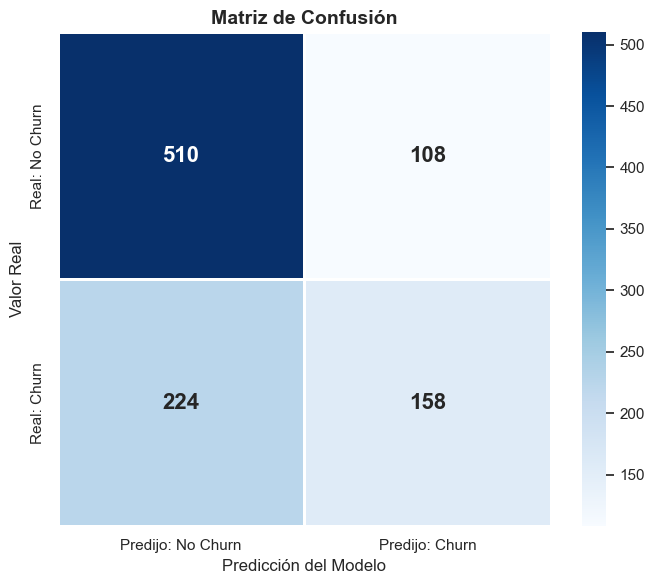

Verdaderos Positivos  (churn detectado):    158
Verdaderos Negativos  (retención correcta): 510
Falsos Positivos      (alarma innecesaria): 108
Falsos Negativos      (churners escapados): 224


In [12]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predijo: No Churn', 'Predijo: Churn'],
    yticklabels=['Real: No Churn',    'Real: Churn'],
    ax=ax, linewidths=1, linecolor='white',
    annot_kws={'size': 16, 'weight': 'bold'}
)

ax.set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_xlabel('Predicción del Modelo', fontsize=12)

vn = cm[0, 0]  # Verdaderos Negativos
fp = cm[0, 1]  # Falsos Positivos
fn = cm[1, 0]  # Falsos Negativos
vp = cm[1, 1]  # Verdaderos Positivos

plt.tight_layout()
plt.savefig('../reports/10_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Verdaderos Positivos  (churn detectado):    {vp:,}')
print(f'Verdaderos Negativos  (retención correcta): {vn:,}')
print(f'Falsos Positivos      (alarma innecesaria): {fp:,}')
print(f'Falsos Negativos      (churners escapados): {fn:,}')

---
## 12. Curva ROC

La curva ROC muestra cómo cambia el rendimiento del modelo según el umbral de decisión.  
Por defecto, el modelo predice churn si la probabilidad es > 0.5. Pero podemos bajar ese umbral a 0.3 para detectar más churners (mayor recall) a costa de más falsas alarmas.

**Área bajo la curva (AUC):** cuanto más cerca de 1.0, mejor. La diagonal es el azar puro.

c:\Users\adria\OneDrive\Desktop\01PROYECTOS\ProyectoMLClientes\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


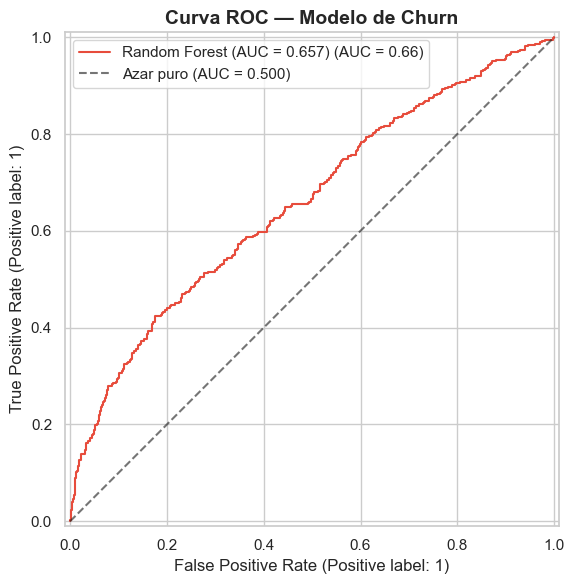

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_pred_proba,
    name=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})',
    color=COLOR_CHURN,
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Azar puro (AUC = 0.500)', alpha=0.6)
ax.set_title('Curva ROC — Modelo de Churn', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../reports/11_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 13. Importancia de variables

El Random Forest nos dice qué tan importante fue cada variable para tomar sus decisiones.  
Esto es muy valioso para el negocio: muestra qué acciones tienen más impacto en la retención.

Una variable con alta importancia significa que el modelo la usó mucho para separar churners de no-churners.

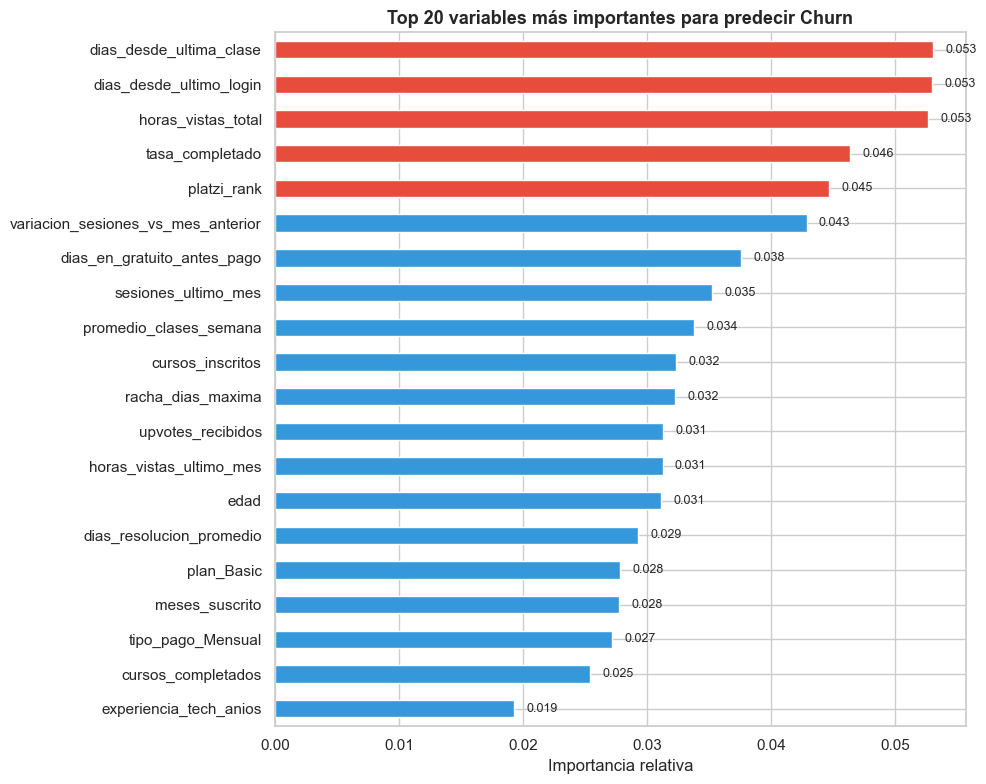

In [14]:
# Extraer nombres de features después del OneHotEncoder
rf = pipeline_completo.named_steps['modelo']
prep = pipeline_completo.named_steps['preprocesador']

nombres_cat = prep.named_transformers_['cat']['encoder'].get_feature_names_out(FEATURES_CATEGORICAS)
nombres_features = FEATURES_NUMERICAS + list(nombres_cat)

importancias = pd.Series(
    rf.feature_importances_,
    index=nombres_features
).sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))

colores = [COLOR_CHURN if i >= len(importancias) - 5 else '#3498db' for i in range(len(importancias))]
importancias.plot(kind='barh', ax=ax, color=colores, edgecolor='white')

ax.set_title('Top 20 variables más importantes para predecir Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')

for bar in ax.patches:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/12_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. Validación cruzada

El train/test split divide los datos una sola vez. Pero ¿qué pasa si por azar ese 20% de test era fácil de predecir?  

La **validación cruzada** divide los datos en 5 partes iguales y repite el entrenamiento 5 veces, cada vez usando una parte diferente como test. El resultado final es el promedio de las 5 evaluaciones — mucho más confiable.

Usamos `AUC-ROC` como métrica porque captura mejor el rendimiento real en datos desbalanceados.

In [15]:
print('Ejecutando validación cruzada (5 folds)... puede tardar unos segundos.')

scores_cv = cross_val_score(
    pipeline_completo, X, y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(f'\nAUC-ROC por fold:')
for i, score in enumerate(scores_cv, 1):
    print(f'  Fold {i}: {score:.4f}')

print(f'\nPromedio: {scores_cv.mean():.4f}')
print(f'Desv. estándar: {scores_cv.std():.4f}  ← si es bajo, el modelo es estable')

Ejecutando validación cruzada (5 folds)... puede tardar unos segundos.

AUC-ROC por fold:
  Fold 1: 0.6852
  Fold 2: 0.6068
  Fold 3: 0.6615
  Fold 4: 0.6579
  Fold 5: 0.6710

Promedio: 0.6565
Desv. estándar: 0.0266  ← si es bajo, el modelo es estable


---
## 15. Guardar el modelo

Guardamos el pipeline completo (preprocesador + modelo) en un archivo `.pkl`.  
Esto nos permite cargarlo en Streamlit sin necesidad de volver a entrenarlo cada vez.

`joblib` es la herramienta estándar para guardar modelos de scikit-learn.

In [16]:
ruta_modelo = '../models/churn_model.pkl'
joblib.dump(pipeline_completo, ruta_modelo)
print(f'Modelo guardado en: {ruta_modelo}')

# Verificar que se puede cargar correctamente
modelo_cargado = joblib.load(ruta_modelo)
print('Verificación: modelo cargado exitosamente.')

Modelo guardado en: ../models/churn_model.pkl
Verificación: modelo cargado exitosamente.


---
## 16. Prueba con un estudiante nuevo

Simulamos cómo funcionaría el modelo en producción: le damos los datos de un estudiante nuevo y el modelo devuelve la probabilidad de que abandone.

In [17]:
# Perfil de un estudiante con señales de riesgo
estudiante_riesgo = pd.DataFrame([{
    'edad': 24,
    'meses_suscrito': 2,
    'cursos_inscritos': 4,
    'cursos_completados': 0,
    'tasa_completado': 0.0,
    'certificados_obtenidos': 0,
    'rutas_inscritas': 1,
    'rutas_completadas': 0,
    'examenes_ruta_aprobados': 0,
    'dias_desde_ultimo_login': 38,
    'dias_desde_ultima_clase': 42,
    'sesiones_ultimo_mes': 1,
    'horas_vistas_total': 3,
    'horas_vistas_ultimo_mes': 0,
    'promedio_clases_semana': 0.0,
    'racha_dias_maxima': 3,
    'racha_dias_actual': 0,
    'liveclasses_asistidas': 0,
    'preguntas_en_foro': 0,
    'respuestas_en_foro': 0,
    'upvotes_recibidos': 0,
    'tutoriales_publicados': 0,
    'platzi_rank': 12,
    'tickets_soporte': 2,
    'dias_resolucion_promedio': 5.0,
    'nps_score': 4.0,
    'intentos_pago_fallidos': 1,
    'variacion_sesiones_vs_mes_anterior': -6.0,
    'experiencia_tech_anios': 0,
    'dias_en_gratuito_antes_pago': 5,
    'plan': 'Basic',
    'pais': 'Colombia',
    'genero': 'Masculino',
    'escuela_principal': 'Escuela de Programacion y Software',
    'dispositivo_principal': 'Mobile',
    'tipo_pago': 'Mensual',
    'objetivo_estudiante': 'Conseguir empleo tech',
    'nivel_educativo': 'Universitario en curso',
    'nivel_rewards': 'Estandar',
}])

prob_churn = modelo_cargado.predict_proba(estudiante_riesgo)[0, 1]
pred_clase = modelo_cargado.predict(estudiante_riesgo)[0]

print('=' * 45)
print('PREDICCIÓN PARA ESTUDIANTE NUEVO')
print('=' * 45)
print(f'  Probabilidad de churn: {prob_churn:.1%}')
print(f'  Clasificación:         {"CHURN" if pred_clase == 1 else "NO CHURN"}')
print()
if prob_churn > 0.7:
    print('  ACCION SUGERIDA: Enviar campaña de retención urgente')
elif prob_churn > 0.4:
    print('  ACCION SUGERIDA: Email de re-engagement con contenido personalizado')
else:
    print('  ACCION SUGERIDA: Ninguna — estudiante con bajo riesgo')
print('=' * 45)

PREDICCIÓN PARA ESTUDIANTE NUEVO
  Probabilidad de churn: 79.0%
  Clasificación:         CHURN

  ACCION SUGERIDA: Enviar campaña de retención urgente


---
## Resumen final

Con este notebook construimos el modelo completo de Churn Prediction para Platzi:

1. Seleccionamos las variables más relevantes
2. Preparamos los datos para que el modelo los entienda (Pipeline)
3. Entrenamos un Random Forest con 200 árboles
4. Evaluamos con métricas apropiadas para datos desbalanceados
5. Analizamos qué variables tienen más impacto en el churn
6. Guardamos el modelo para usarlo en Streamlit

